# 802.11a TX Chain

Demonstrates the full transmitter pipeline:

```
Random bits → FEC (scramble → conv encode → puncture)
            → Interleave
            → Constellation mapping
            → OFDM modulate (pilots + IFFT + cyclic prefix)
```

In [1]:
import sys
import os

# Ensure the python/ directory is on the path when running from any cwd
module_dir = os.path.dirname(os.path.abspath("__file__"))
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from config import ModulationTypes, CodingRates, LinkSettings
from fec_module import perform_FEC
from interleaver_module import interleave
from modulation_module import map_bits_to_constellation
from ofdm_module import OFDMModule
from preamble_module import PreambleModule


rng = np.random.default_rng(seed=41)

## 1 — Generate 1000 random input bits

In [2]:
NUM_BITS = 1000
input_bits = rng.integers(0, 2, size=NUM_BITS)

print(f"Input bits : {NUM_BITS}")
print(f"First 32   : {input_bits[:32]}")

Input bits : 1000
First 32   : [1 1 1 1 1 0 0 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 0 1 0 0 0 0 0 1 1 1]


## 2 — TX Parameters

In [3]:
MODULATION    = ModulationTypes.QAM64   # change to QPSK / QAM16 / QAM64 to explore
CODING_RATE   = CodingRates.R23
SCRAMBLER_SEED = 0x5D                  # arbitrary non-zero 7-bit seed

link = LinkSettings(modulationType=MODULATION)

N_DATA_SC  = link.numSubcarriers - link.numPilots  # 48 data subcarriers
N_BPSC     = link.bitPerSubcarrier[MODULATION]     # bits per subcarrier
N_CBPS     = N_BPSC * N_DATA_SC                   # coded bits per OFDM symbol

SAMPLE_RATE_HZ = link.nFFT / link.T               # ~20 MHz

print(f"Modulation : {MODULATION}  ({N_BPSC} bit/subcarrier)")
print(f"Coding rate: {CODING_RATE}")
print(f"N_CBPS     : {N_CBPS} bits/OFDM symbol")
print(f"Sample rate: {SAMPLE_RATE_HZ/1e6:.1f} MHz")

Modulation : QAM64  (6 bit/subcarrier)
Coding rate: R23
N_CBPS     : 288 bits/OFDM symbol
Sample rate: 20.0 MHz


## 3 — FEC: Scramble → Convolutional Encode → Puncture

In [4]:
fec_bits = np.array(perform_FEC(input_bits, CODING_RATE, SCRAMBLER_SEED), dtype=int)

# Pad to the next integer multiple of N_CBPS
pad_len   = (-len(fec_bits)) % N_CBPS
fec_bits  = np.append(fec_bits, np.zeros(pad_len, dtype=int))

num_ofdm_symbols = len(fec_bits) // N_CBPS

print(f"FEC output : {len(fec_bits)} bits  ({num_ofdm_symbols} OFDM symbols, {pad_len} pad bits)")

FEC output : 1728 bits  (6 OFDM symbols, 219 pad bits)


## 4 — Interleave

In [5]:
interleaved_bits = np.empty_like(fec_bits)
for sym_idx in range(num_ofdm_symbols):
    block = fec_bits[sym_idx * N_CBPS : (sym_idx + 1) * N_CBPS]
    interleaved_bits[sym_idx * N_CBPS : (sym_idx + 1) * N_CBPS] = interleave(block, N_CBPS, N_BPSC)

print(f"Interleaved bits: {len(interleaved_bits)}")

Interleaved bits: 1728


## 5 — Constellation Mapping

In [6]:
symbols = map_bits_to_constellation(list(interleaved_bits), MODULATION, N_BPSC)
symbols = np.array(symbols)

print(f"Constellation symbols: {len(symbols)}")
print(f"Unique I/Q points    : {len(set(symbols))}")

Constellation symbols: 288
Unique I/Q points    : 63


## 6 — OFDM Modulate

In [7]:
ofdm = OFDMModule(link)
tx_signal = ofdm.modulate(symbols)

samples_per_sym = link.nFFT + link.cpLenData  # 80
t = np.arange(len(tx_signal)) / SAMPLE_RATE_HZ * 1e6  # time axis in µs

print(f"TX signal length : {len(tx_signal)} samples")
print(f"TX duration      : {t[-1]:.1f} µs  ({num_ofdm_symbols} × {samples_per_sym} samples/symbol)")

TX signal length : 480 samples
TX duration      : 23.9 µs  (6 × 80 samples/symbol)


## 6b - Preamble

In [8]:
preamble_module = PreambleModule(link)
preamble_signal = preamble_module.generate_preamble()

tx_signal = np.concatenate([preamble_signal, tx_signal])

print(f"Preamble signal length: {len(preamble_signal)} samples")
print(f"Preamble duration: {len(preamble_signal) / SAMPLE_RATE_HZ * 1e6:.1f} µs")

Preamble signal length: 320 samples
Preamble duration: 16.0 µs


## 7 — Plots

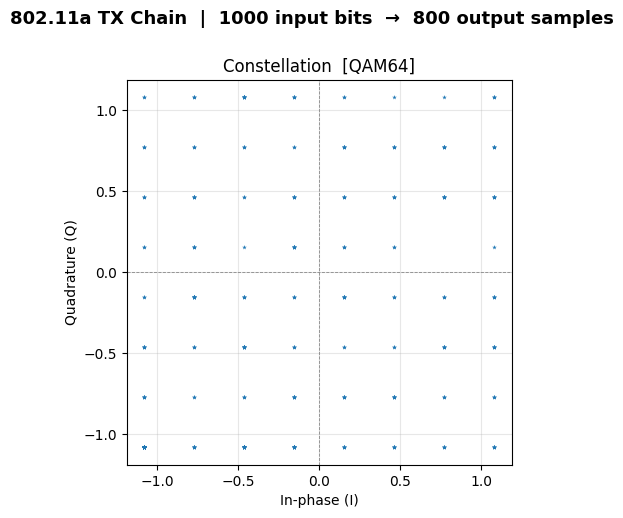

Saved → tx_chain_constellation.png


In [9]:
fig, ax_const = plt.subplots(figsize=(6, 5))

# ── Constellation ────────────────────────────────────────────────────────────
ax_const.scatter(
    symbols.real, symbols.imag, marker="*",
    s=12, linewidths=0,
)
ax_const.axhline(0, color="#888", lw=0.6, ls="--")
ax_const.axvline(0, color="#888", lw=0.6, ls="--")
ax_const.set_xlabel("In-phase (I)")
ax_const.set_ylabel("Quadrature (Q)")
ax_const.set_title(f"Constellation  [{MODULATION}]")
ax_const.set_aspect("equal")
ax_const.grid(True, alpha=0.3)

plt.suptitle(
    f"802.11a TX Chain  |  {NUM_BITS} input bits  →  {len(tx_signal)} output samples",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.savefig("tx_chain_constellation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tx_chain_constellation.png")

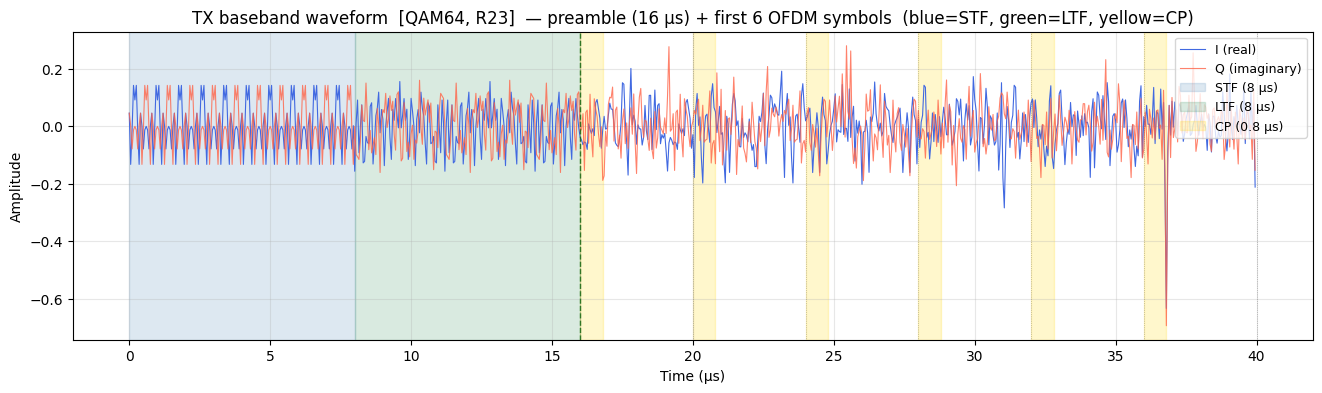

Saved → tx_chain_waveform.png


In [10]:
fig, ax_wave = plt.subplots(figsize=(16, 4))

# Rebuild time axis for the full tx_signal (preamble + OFDM data)
t_full = np.arange(len(tx_signal)) / SAMPLE_RATE_HZ * 1e6

preamble_len = len(preamble_signal)                      # 320 samples
stf_len      = 160                                        # 10 × 16-sample periods
preamble_dur = preamble_len / SAMPLE_RATE_HZ * 1e6       # 16 µs
stf_dur      = stf_len      / SAMPLE_RATE_HZ * 1e6       #  8 µs

# Show preamble + first N OFDM symbols
n_ofdm_show = min(6, num_ofdm_symbols)
n_show      = min(preamble_len + n_ofdm_show * samples_per_sym, len(tx_signal))

t_show   = t_full[:n_show]
sig_show = tx_signal[:n_show]

ax_wave.plot(t_show, sig_show.real, label="I (real)",      color="royalblue", lw=0.8)
ax_wave.plot(t_show, sig_show.imag, label="Q (imaginary)", color="tomato",    lw=0.8, alpha=0.8)

# Shade preamble regions: STF (blue) and LTF (green)
ax_wave.axvspan(0,        stf_dur,      color="steelblue", alpha=0.18, label="STF (8 µs)")
ax_wave.axvspan(stf_dur,  preamble_dur, color="seagreen",  alpha=0.18, label="LTF (8 µs)")

# Mark preamble / data boundary
ax_wave.axvline(preamble_dur, color="darkgreen", lw=1.0, ls="--", alpha=0.8)

# Mark OFDM symbol boundaries (offset by preamble)
for sym_i in range(n_ofdm_show + 1):
    x_mark = preamble_dur + sym_i * samples_per_sym / SAMPLE_RATE_HZ * 1e6
    ax_wave.axvline(x_mark, color="#555", lw=0.5, ls=":", alpha=0.6)

# Shade cyclic-prefix regions (offset by preamble)
for sym_i in range(n_ofdm_show):
    cp_start = preamble_dur + sym_i * samples_per_sym / SAMPLE_RATE_HZ * 1e6
    cp_end   = cp_start + link.cpLenData / SAMPLE_RATE_HZ * 1e6
    ax_wave.axvspan(cp_start, cp_end, color="gold", alpha=0.20,
                    label="CP (0.8 µs)" if sym_i == 0 else None)

ax_wave.set_xlabel("Time (µs)")
ax_wave.set_ylabel("Amplitude")
ax_wave.set_title(
    f"TX baseband waveform  [{MODULATION}, {CODING_RATE}]  "
    f"— preamble (16 µs) + first {n_ofdm_show} OFDM symbols  "
    f"(blue=STF, green=LTF, yellow=CP)"
)
ax_wave.legend(loc="upper right", fontsize=9)
ax_wave.grid(True, alpha=0.3)

plt.savefig("tx_chain_waveform.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tx_chain_waveform.png")